In [30]:
import sklearn
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
import os

In [31]:
def resize_with_padding(img, target_size, pad_value=255):
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

    canvas = np.full((target_size, target_size), pad_value, dtype=img.dtype)
    x_off = (target_size - new_w) // 2
    y_off = (target_size - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def preprocess_fish_image(image_path, target_size, margin=5):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY_INV)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    h, w = gray.shape
    valid = [c for c in contours
             if cv2.boundingRect(c)[2] < w - 10 and cv2.contourArea(c) > 500]

    if not valid:
        return resize_with_padding(gray, target_size)

    mask = np.zeros_like(gray)
    cv2.drawContours(mask, valid, -1, 255, -1)

    extracted = gray.copy()
    extracted[mask == 0] = 255

    x, y, bw, bh = cv2.boundingRect(np.vstack(valid))
    x0, y0 = max(x - margin, 0), max(y - margin, 0)
    x1, y1 = min(x + bw + margin, w), min(y + bh + margin, h)
    cropped = extracted[y0:y1, x0:x1]

    return resize_with_padding(cropped, target_size)

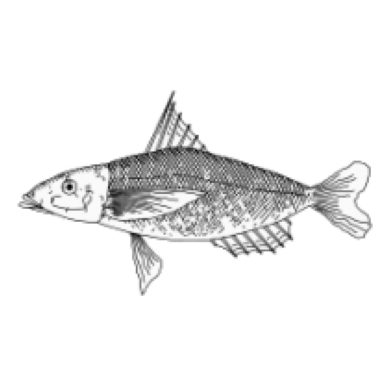

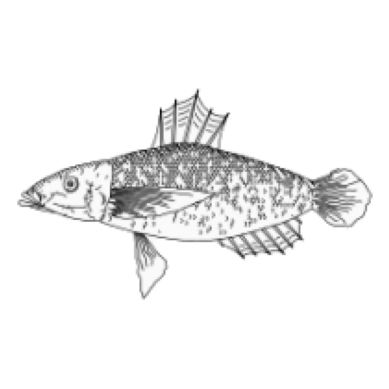

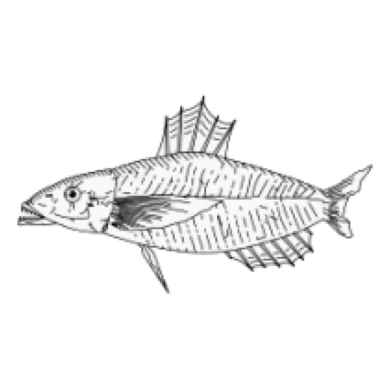

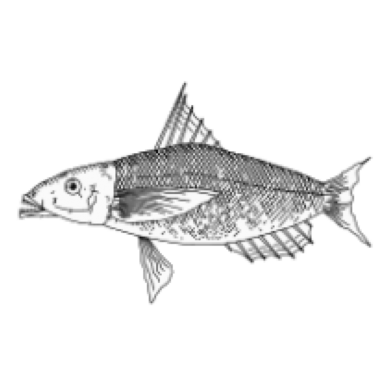

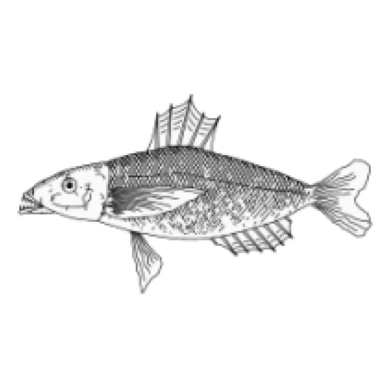

coucou


In [32]:
for i in range(1, 6):
    image_path = f"lot0/fish_0000{i}.png"
    processed_image = preprocess_fish_image(image_path, 250)
    plt.imshow(processed_image, cmap='gray')
    plt.axis('off')
    plt.show()

In [ ]:
input_folder = "./lot0"
data = "./lot0/labels.csv"

labels_df = pd.read_csv(data).set_index("filename")
label_columns = labels_df.columns.tolist()

images = []
labels = []
filenames = []

for filename in sorted(os.listdir(input_folder)):
    if not filename.endswith(".png"):
        continue

    if filename not in labels_df.index:
        print(f"No label for {filename}, skipped")
        continue

    image_path = os.path.join(input_folder, filename)
    image = preprocess_fish_image(image_path, 250)
    if image is None:
        print(f"Could not read {filename}, skipped")
        continue

    images.append(image)
    labels.append(labels_df.loc[filename].values)
    filenames.append(filename)

X_images = np.array(images)
y_labels = np.array(labels)

print(X_images.shape, y_labels.shape)
print(filenames[0], dict(zip(label_columns, y_labels[0])))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import copy

SIZES = [4, 2, 2, 2, 6, 2, 2]
NAMES = ["scale", "dorsal", "wing", "pelvic", "tail", "eye", "teeth"]

X_t = torch.tensor(X_images, dtype=torch.float)
y_t = torch.tensor(y_labels, dtype=torch.long)

X_t = X_t.unsqueeze(1)
X_t = X_t / 255.0 

dataset = TensorDataset(X_t, y_t)
train_set, test_set = random_split(dataset, [80, 20], generator=torch.Generator().manual_seed(69))

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=16, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.AdaptiveAvgPool2d((20, 32))
        )
        self.fc = nn.Sequential(
            nn.Linear(64*20*32,256), nn.ReLU(),
            nn.Linear(256,64), nn.ReLU(),
            nn.Linear(64, sum(SIZES))
        )

    def forward(self,x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0),-1))

model = CNN()

def split(out):
    return torch.split(out, SIZES, dim=1)

opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

best_loss = float("inf")
best_state = None
nb_epoch = 60
for epoch in range(nb_epoch):
    model.train()
    running_loss = 0.0
    n_batches = 0
    
    for x,y in train_loader:
        opt.zero_grad()
        groups = split(model(x))
        loss = 0                                         
        for i in range(7):                                
            loss = loss + loss_fn(groups[i], y[:, i])     
        loss.backward()
        opt.step()
        running_loss += loss.item()
        n_batches += 1
        
    avg_loss = running_loss / n_batches
    print(f"Epoch {epoch+1}/{nb_epoch} - loss: {avg_loss:.4f}")

    #Save loss if is best
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)


def accuracy(loader):
    model.eval()
    correct = [0] * 7
    total = 0
    with torch.no_grad():
        for x, y in loader:
            groups = split(model(x))
            for i in range(7):
                pred = groups[i].argmax(1)
                correct[i] += (pred == y[:, i]).sum().item()
            total += y.size(0)
    return [100 * c / total for c in correct]

train_acc = accuracy(train_loader)
test_acc = accuracy(test_loader)

for i in range(7):
    print(f"{NAMES[i]:>7}: train {train_acc[i]:5.1f} %   test {test_acc[i]:5.1f} %")
    
print(f"Mean accuracy: train {sum(train_acc)/7:.1f} %   test {sum(test_acc)/7:.1f} %")

In [ ]:
def predict_folder(model, folder, output_csv, label_columns, target_shape=None):
    model.eval()
    files = sorted(f for f in os.listdir(folder) if f.endswith(".png"))
    rows = []

    with torch.no_grad():
        for filename in files:
            path = os.path.join(folder, filename)
            img = preprocess_fish_image(path, 250)
            if img is None:
                print(f"Could not read {filename}, skipped")
                continue

            if target_shape is not None and img.shape != target_shape:
                img = cv2.resize(img, (target_shape[1], target_shape[0]))

            x = torch.tensor(img, dtype=torch.float).unsqueeze(0).unsqueeze(0) / 255.0

            groups = split(model(x))
            preds = [g.argmax(1).item() for g in groups]
            rows.append([filename] + preds)

    df = pd.DataFrame(rows, columns=["filename"] + label_columns)
    df.to_csv(output_csv, index=False)
    print(f"{len(df)} predictions saved to {output_csv}")
    return df


pred_df = predict_folder(
    model,
    folder="./lot1",                       
    output_csv="./lot1/predictions.csv",
    label_columns=label_columns,          
    target_shape=X_images.shape[1:],
)
print(pred_df.head())